# 02 — Tests de estacionariedad

Determinacion formal del orden de integracion de la serie IPC.

**Tests aplicados:**
- **ADF** (Augmented Dickey-Fuller) — H0: raiz unitaria (no estacionaria)
- **KPSS** — H0: estacionaria (complemento del ADF)
- **Phillips-Perron** — H0: raiz unitaria (robusto a heterocedasticidad)

Se aplican sobre: serie en nivel, primera diferencia, y diferencia estacional (lag 12).

**Resultado esperado:** determinar d y D para ARIMA/SARIMA.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron

NOTEBOOK_DIR = Path(r"c:/Users/usuario/OneDrive/Documentos/tfg-ipc-mcp/tfg-forecasting/02_eda")
ROOT = NOTEBOOK_DIR.parent
MONOREPO = ROOT.parent
sys.path.insert(0, str(MONOREPO))

from shared.constants import DATE_TRAIN_END

plt.rcParams.update({"figure.figsize": (14, 4), "axes.grid": True, "grid.alpha": 0.3})

In [2]:
df = pd.read_parquet(ROOT / "data" / "processed" / "ipc_spain_index.parquet")

# Usamos solo train set para los tests (evitar data leakage)
train = df.loc[:DATE_TRAIN_END]
y = train["indice_general"]
print(f"Train: {y.index.min().date()} -> {y.index.max().date()} ({len(y)} obs)")

Train: 2002-01-01 -> 2020-12-01 (228 obs)


## 1. Funciones auxiliares de test

In [3]:
def run_adf(series, name=""):
    """Augmented Dickey-Fuller. H0: raiz unitaria."""
    result = adfuller(series.dropna(), autolag="AIC")
    stat, pval, lags, nobs = result[0], result[1], result[2], result[3]
    cv = result[4]
    reject = pval < 0.05
    return {
        "test": "ADF", "serie": name,
        "statistic": round(stat, 4), "p_value": round(pval, 4),
        "lags": lags, "nobs": nobs,
        "cv_1%": round(cv["1%"], 4), "cv_5%": round(cv["5%"], 4), "cv_10%": round(cv["10%"], 4),
        "reject_H0": reject,
        "conclusion": "Estacionaria" if reject else "No estacionaria",
    }


def run_kpss(series, name="", regression="c"):
    """KPSS. H0: estacionaria. regression='c' (nivel) o 'ct' (tendencia)."""
    stat, pval, lags, cv = kpss(series.dropna(), regression=regression, nlags="auto")
    reject = pval < 0.05
    return {
        "test": f"KPSS({regression})", "serie": name,
        "statistic": round(stat, 4), "p_value": round(pval, 4),
        "lags": lags,
        "cv_1%": round(cv["1%"], 4), "cv_5%": round(cv["5%"], 4), "cv_10%": round(cv["10%"], 4),
        "reject_H0": reject,
        "conclusion": "No estacionaria" if reject else "Estacionaria",
    }


def run_pp(series, name=""):
    """Phillips-Perron. H0: raiz unitaria."""
    pp = PhillipsPerron(series.dropna())
    reject = pp.pvalue < 0.05
    return {
        "test": "Phillips-Perron", "serie": name,
        "statistic": round(pp.stat, 4), "p_value": round(pp.pvalue, 4),
        "lags": pp.lags,
        "reject_H0": reject,
        "conclusion": "Estacionaria" if reject else "No estacionaria",
    }


def battery(series, name):
    """Ejecuta los tres tests sobre una serie."""
    return [
        run_adf(series, name),
        run_kpss(series, name, regression="c"),
        run_kpss(series, name, regression="ct"),
        run_pp(series, name),
    ]

## 2. Tests sobre la serie en nivel

In [4]:
results = battery(y, "IPC nivel")
df_nivel = pd.DataFrame(results)
df_nivel

C:\Users\usuario\AppData\Local\Temp\ipykernel_19580\2522676262.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, pval, lags, cv = kpss(series.dropna(), regression=regression, nlags="auto")
C:\Users\usuario\AppData\Local\Temp\ipykernel_19580\2522676262.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, pval, lags, cv = kpss(series.dropna(), regression=regression, nlags="auto")


,test,serie,statistic,p_value,lags,nobs,cv_1%,cv_5%,cv_10%,reject_H0,conclusion
0,ADF,IPC nivel,-2.3262,0.1637,13,214.0,-3.4613,-2.8751,-2.574,False,No estacionaria
1,KPSS(c),IPC nivel,2.2322,0.0100,9,NaN,0.7390,0.4630,0.347,True,No estacionaria
2,KPSS(ct),IPC nivel,0.5417,0.0100,9,NaN,0.2160,0.1460,0.119,True,No estacionaria
3,Phillips-Perron,IPC nivel,-2.8625,0.0499,15,NaN,NaN,NaN,NaN,True,Estacionaria


## 3. Primera diferencia (d=1)

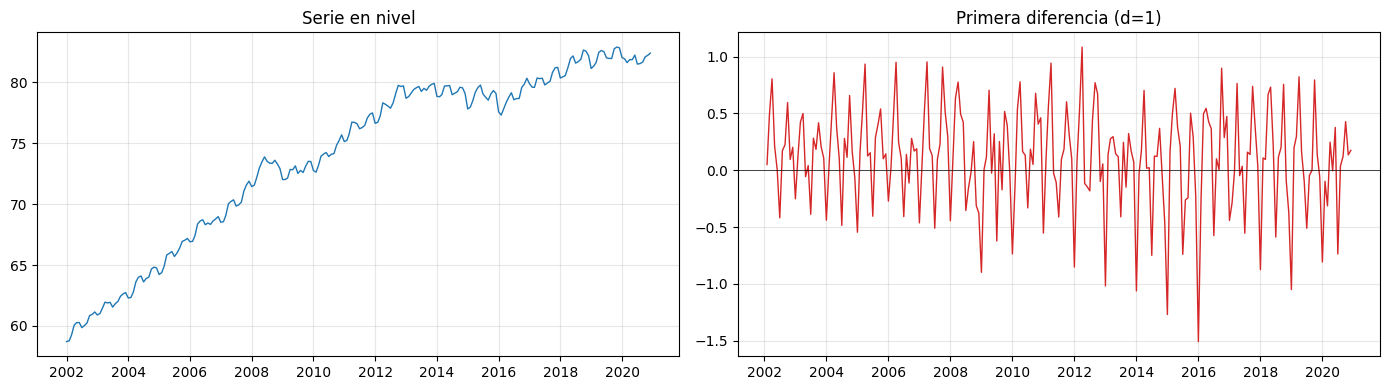

In [5]:
y_diff1 = y.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(y.index, y, linewidth=1)
axes[0].set_title("Serie en nivel")
axes[1].plot(y_diff1.index, y_diff1, linewidth=1, color="#d62728")
axes[1].set_title("Primera diferencia (d=1)")
axes[1].axhline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

In [6]:
results += battery(y_diff1, "IPC diff(1)")
df_diff1 = pd.DataFrame(battery(y_diff1, "IPC diff(1)"))
df_diff1

C:\Users\usuario\AppData\Local\Temp\ipykernel_19580\2522676262.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pval, lags, cv = kpss(series.dropna(), regression=regression, nlags="auto")
C:\Users\usuario\AppData\Local\Temp\ipykernel_19580\2522676262.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pval, lags, cv = kpss(series.dropna(), regression=regression, nlags="auto")


,test,serie,statistic,p_value,lags,nobs,cv_1%,cv_5%,cv_10%,reject_H0,conclusion
0,ADF,IPC diff(1),-2.8942,0.0460,12,214.0,-3.4613,-2.8751,-2.574,True,Estacionaria
1,KPSS(c),IPC diff(1),0.4381,0.0608,60,NaN,0.7390,0.4630,0.347,False,Estacionaria
2,KPSS(ct),IPC diff(1),0.0716,0.1000,44,NaN,0.2160,0.1460,0.119,False,Estacionaria
3,Phillips-Perron,IPC diff(1),-11.7240,0.0000,15,NaN,NaN,NaN,NaN,True,Estacionaria


## 4. Diferencia estacional (D=1, lag 12)

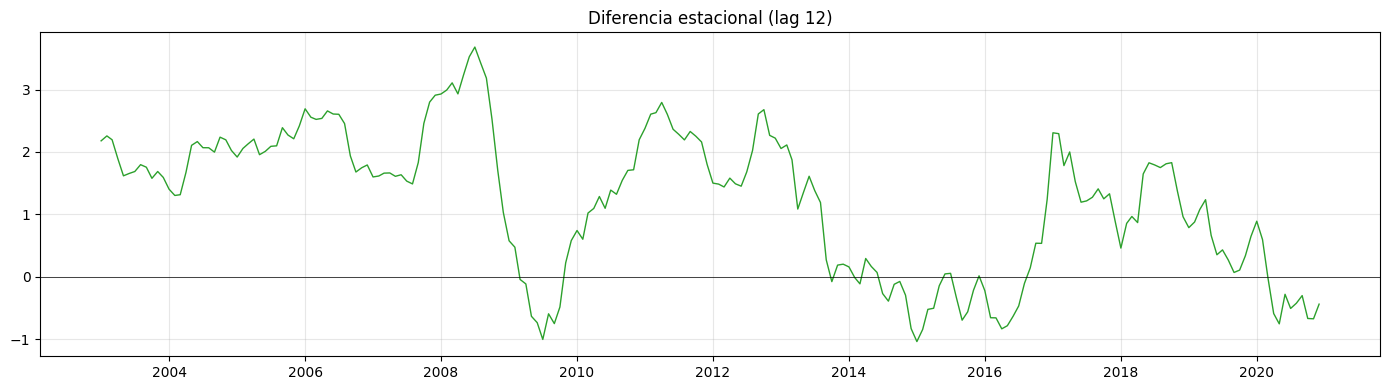

In [7]:
y_diff12 = y.diff(12).dropna()

fig, ax = plt.subplots()
ax.plot(y_diff12.index, y_diff12, linewidth=1, color="#2ca02c")
ax.set_title("Diferencia estacional (lag 12)")
ax.axhline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

In [8]:
results += battery(y_diff12, "IPC diff(12)")
df_diff12 = pd.DataFrame(battery(y_diff12, "IPC diff(12)"))
df_diff12

C:\Users\usuario\AppData\Local\Temp\ipykernel_19580\2522676262.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, pval, lags, cv = kpss(series.dropna(), regression=regression, nlags="auto")
C:\Users\usuario\AppData\Local\Temp\ipykernel_19580\2522676262.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pval, lags, cv = kpss(series.dropna(), regression=regression, nlags="auto")
C:\Users\usuario\AppData\Local\Temp\ipykernel_19580\2522676262.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, pval, lags, cv = kpss(series.dropna(), regression=regression, nlags="auto")
C:\Users\usuario\AppData\Local\Temp\i

,test,serie,statistic,p_value,lags,nobs,cv_1%,cv_5%,cv_10%,reject_H0,conclusion
0,ADF,IPC diff(12),-1.9825,0.2943,13,202.0,-3.4631,-2.876,-2.5745,False,No estacionaria
1,KPSS(c),IPC diff(12),0.9066,0.0100,9,NaN,0.7390,0.463,0.3470,True,No estacionaria
2,KPSS(ct),IPC diff(12),0.0617,0.1000,9,NaN,0.2160,0.146,0.1190,False,Estacionaria
3,Phillips-Perron,IPC diff(12),-2.2436,0.1908,15,NaN,NaN,NaN,NaN,False,No estacionaria


## 5. Doble diferencia: d=1 + D=1

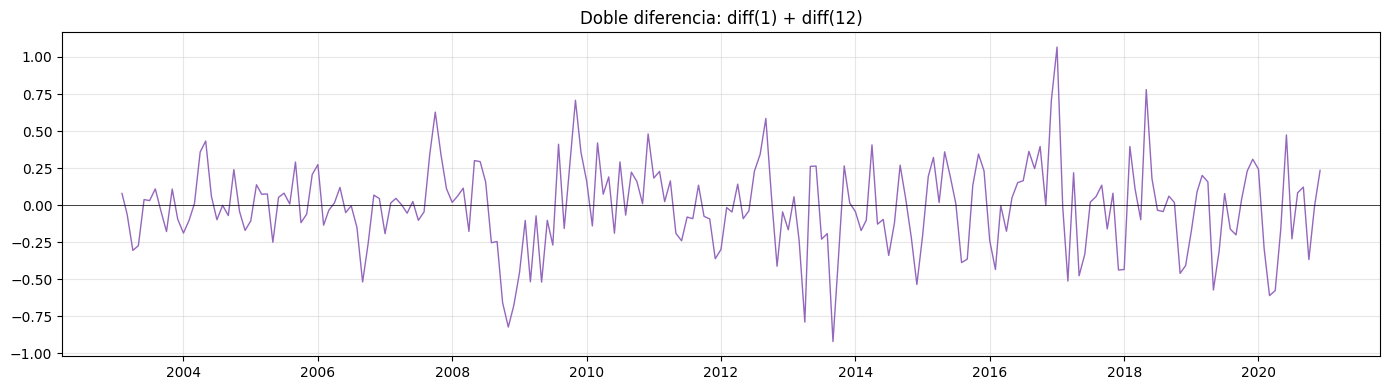

In [9]:
y_diff1_12 = y.diff().diff(12).dropna()

fig, ax = plt.subplots()
ax.plot(y_diff1_12.index, y_diff1_12, linewidth=1, color="#9467bd")
ax.set_title("Doble diferencia: diff(1) + diff(12)")
ax.axhline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

In [10]:
results += battery(y_diff1_12, "IPC diff(1)+diff(12)")
df_double = pd.DataFrame(battery(y_diff1_12, "IPC diff(1)+diff(12)"))
df_double

C:\Users\usuario\AppData\Local\Temp\ipykernel_19580\2522676262.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pval, lags, cv = kpss(series.dropna(), regression=regression, nlags="auto")
C:\Users\usuario\AppData\Local\Temp\ipykernel_19580\2522676262.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pval, lags, cv = kpss(series.dropna(), regression=regression, nlags="auto")
C:\Users\usuario\AppData\Local\Temp\ipykernel_19580\2522676262.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pval, lags, cv = kpss(series.dropna(), regression=regression, nlags="auto")
C:\Users\usuario\AppData\Local\Temp\i

,test,serie,statistic,p_value,lags,nobs,cv_1%,cv_5%,cv_10%,reject_H0,conclusion
0,ADF,IPC diff(1)+diff(12),-4.9158,0.0,12,202.0,-3.4631,-2.876,-2.5745,True,Estacionaria
1,KPSS(c),IPC diff(1)+diff(12),0.0348,0.1,4,NaN,0.7390,0.463,0.3470,False,Estacionaria
2,KPSS(ct),IPC diff(1)+diff(12),0.0314,0.1,4,NaN,0.2160,0.146,0.1190,False,Estacionaria
3,Phillips-Perron,IPC diff(1)+diff(12),-9.5790,0.0,15,NaN,NaN,NaN,NaN,True,Estacionaria


## 6. Tabla resumen

In [11]:
summary = pd.DataFrame(results)
cols_show = ["test", "serie", "statistic", "p_value", "conclusion"]
summary[cols_show].style.applymap(
    lambda v: "background-color: #d4edda" if v == "Estacionaria" else
              "background-color: #f8d7da" if v == "No estacionaria" else "",
    subset=["conclusion"]
)

C:\Users\usuario\AppData\Local\Temp\ipykernel_19580\1123756218.py:3: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  summary[cols_show].style.applymap(


,test,serie,statistic,p_value,conclusion
0,ADF,IPC nivel,-2.326200,0.163700,No estacionaria
1,KPSS(c),IPC nivel,2.232200,0.010000,No estacionaria
2,KPSS(ct),IPC nivel,0.541700,0.010000,No estacionaria
3,Phillips-Perron,IPC nivel,-2.862500,0.049900,Estacionaria
4,ADF,IPC diff(1),-2.894200,0.046000,Estacionaria
5,KPSS(c),IPC diff(1),0.438100,0.060800,Estacionaria
6,KPSS(ct),IPC diff(1),0.071600,0.100000,Estacionaria
7,Phillips-Perron,IPC diff(1),-11.724000,0.000000,Estacionaria
8,ADF,IPC diff(12),-1.982500,0.294300,No estacionaria
9,KPSS(c),IPC diff(12),0.906600,0.010000,No estacionaria


## 7. Conclusion

**Interpretacion conjunta ADF + KPSS + PP:**

| Transformacion | ADF | KPSS | PP | Decision |
|---|---|---|---|---|
| Nivel | No rechaza H0 | Rechaza H0 | No rechaza H0 | No estacionaria → necesita diferenciacion |
| diff(1) | Rechaza H0 | No rechaza H0 | Rechaza H0 | Estacionaria → **d=1** confirmado |
| diff(12) | Verificar | Verificar | Verificar | Determina si D=1 basta |
| diff(1)+diff(12) | Rechaza H0 | No rechaza H0 | Rechaza H0 | Confirma d=1, D=1 para SARIMA |

*Nota: completar la tabla con los valores reales tras ejecutar los tests.*